# Phase 2 - 02: Reward 函数设计

## 本节目标

设计并验证 GRPO 训练所需的 Reward 函数。

## 从 Baseline 观察出发

01 notebook 发现的问题：
- `<think>` 标签经常缺失
- `<tool_call>` 里填的是示例文字，不是真实 Python 表达式
- 最终答案格式不稳定（有时有逗号，可能还会有单位）

## Reward 设计思路

参考 DeepSeek-R1 的两层奖励：

```
总 Reward = 格式奖励 + 结果奖励
```

| 奖励项 | 满分 | 说明 |
|---|---|---|
| 格式奖励 | 0.3 | 三个标签是否都存在且顺序正确 |
| 工具执行奖励 | 0.2 | tool_call 是否是可执行的 Python 表达式 |
| 结果奖励 | 1.0 | 最终答案是否与正确答案一致 |

**为什么分开？**
- 只给结果奖励：模型可能绕过工具直接猜答案（reward hacking）
- 加格式奖励：强制模型走「调用工具」这条路

## 1. 复用 01 的工具函数

In [1]:
import re
import math
import json
import os

# ── 计算器 ──────────────────────────────────────────────
SAFE_MATH_ENV = {
    "__builtins__": {},
    "abs": abs, "round": round, "int": int, "float": float,
    "sqrt": math.sqrt, "pow": math.pow, "floor": math.floor, "ceil": math.ceil,
}

def calculator(expression: str) -> str:
    try:
        expr = expression.strip().replace("^", "**")
        result = eval(expr, SAFE_MATH_ENV)
        if isinstance(result, float) and result.is_integer():
            return str(int(result))
        return str(result)
    except Exception as e:
        return f"ERROR: {e}"

# ── 解析模型输出 ─────────────────────────────────────────
def parse_output(text: str) -> dict:
    result = {"think": None, "tool_call": None, "answer": None}
    for tag in ["think", "tool_call", "answer"]:
        m = re.search(rf"<{tag}>(.*?)</{tag}>", text, re.DOTALL)
        if m:
            result[tag] = m.group(1).strip()
    return result

# ── GSM8K 答案提取 ───────────────────────────────────────
def extract_gsm8k_answer(answer_str: str) -> str:
    m = re.search(r"####\s*([\d,]+)", answer_str)
    return m.group(1).replace(",", "") if m else None

print("工具函数加载完成")

工具函数加载完成


## 2. 格式奖励

检查输出中三个标签是否都存在。

In [2]:
def format_reward(output: str) -> float:
    """
    检查三个标签是否都存在且顺序正确：
    <think>...</think> 在前，<tool_call>...</tool_call> 居中，<answer>...</answer> 在后。
    满分 0.3，每缺一个标签扣 0.1。
    """
    parsed = parse_output(output)
    score = 0.0
    if parsed["think"] is not None:     score += 0.1
    if parsed["tool_call"] is not None: score += 0.1
    if parsed["answer"] is not None:    score += 0.1
    return round(score, 2)


# 测试
cases = [
    ("完整格式",
     "<think>分析</think><tool_call>15-7+3</tool_call><answer>11</answer>"),
    ("缺 think",
     "<tool_call>15-7+3</tool_call><answer>11</answer>"),
    ("只有 answer",
     "<answer>11</answer>"),
    ("无标签（baseline 情况）",
     "答案是11。"),
]

print("格式奖励测试：")
for name, text in cases:
    print(f"  {name:20} => {format_reward(text)}")

格式奖励测试：
  完整格式                 => 0.3
  缺 think              => 0.2
  只有 answer            => 0.1
  无标签（baseline 情况）     => 0.0


## 3. 工具执行奖励

检查 `tool_call` 里的内容是否是可执行的 Python 表达式（而不是示例文字）。

In [3]:
def tool_execution_reward(output: str) -> float:
    """
    tool_call 内容能被计算器成功执行，得 0.2；
    tool_call 不存在或执行出错，得 0。
    """
    parsed = parse_output(output)
    if not parsed["tool_call"]:
        return 0.0
    result = calculator(parsed["tool_call"])
    return 0.2 if not result.startswith("ERROR") else 0.0


# 测试
cases = [
    ("真实表达式",      "<tool_call>15 - 7 + 3</tool_call>"),
    ("示例文字（baseline）", "<tool_call>Python 表达式（例如：15 - 7 + 3）</tool_call>"),
    ("无 tool_call",   "<answer>11</answer>"),
    ("复杂表达式",      "<tool_call>(48 + 48/2)</tool_call>"),
]

print("工具执行奖励测试：")
for name, text in cases:
    print(f"  {name:20} => {tool_execution_reward(text)}")

工具执行奖励测试：
  真实表达式                => 0.2
  示例文字（baseline）       => 0.0
  无 tool_call          => 0.0
  复杂表达式                => 0.2


## 4. 结果奖励

最终答案是否正确。比较时做数字归一化（去掉逗号、单位、空格）。

In [6]:
def normalize_answer(s: str) -> str:
    """归一化答案字符串，便于比较。"""
    if s is None:
        return ""
    s = s.strip()
    s = re.sub(r"[,，]", "", s)           # 去掉逗号（1,000 -> 1000）
    s = re.sub(r"[^0-9\.\-]", "", s)     # 只保留数字、小数点、负号
    # 去掉末尾多余的小数零（10.0 -> 10）
    try:
        f = float(s)
        return str(int(f)) if f == int(f) else str(f)
    except:
        return s


def answer_reward(output: str, correct_answer: str) -> float:
    """
    模型 <answer> 与正确答案一致得 1.0，否则得 0.0。
    比较前做归一化。
    """
    parsed = parse_output(output)
    if not parsed["answer"]:
        return 0.0
    pred = normalize_answer(parsed["answer"])
    gold = normalize_answer(correct_answer)
    return 1.0 if pred == gold else 0.0


# 测试
cases = [
    ("精确匹配",         "<answer>72</answer>",       "72"),
    ("有逗号",           "<answer>1,000</answer>",    "1000"),
    ("小数归整",         "<answer>10.0</answer>",     "10"),
    ("带单位（错误）",    "<answer>18,000 dollars</answer>", "18000"),
    ("答案错误",         "<answer>11</answer>",       "72"),
    ("无 answer 标签",   "答案是72。",                "72"), # "72"同样不对
]

print("结果奖励测试：")
for name, output, gold in cases:
    r = answer_reward(output, gold)
    pred = normalize_answer(parse_output(output)["answer"])
    print(f"  {name:18} => {r}  (pred={pred!r:8} gold={normalize_answer(gold)!r})")

结果奖励测试：
  精确匹配               => 1.0  (pred='72'     gold='72')
  有逗号                => 1.0  (pred='1000'   gold='1000')
  小数归整               => 1.0  (pred='10'     gold='10')
  带单位（错误）            => 1.0  (pred='18000'  gold='18000')
  答案错误               => 0.0  (pred='11'     gold='72')
  无 answer 标签        => 0.0  (pred=''       gold='72')


## 5. 组合 Reward 函数

GRPO 需要的接口：给定一批 `(output, correct_answer)`，返回每个的 reward 分数。

In [7]:
def compute_reward(output: str, correct_answer: str) -> dict:
    """
    计算单条输出的完整 reward。
    返回各分项和总分，便于分析训练过程。
    """
    r_format = format_reward(output)
    r_tool   = tool_execution_reward(output)
    r_answer = answer_reward(output, correct_answer)
    total    = r_format + r_tool + r_answer
    return {
        "format":  r_format,
        "tool":    r_tool,
        "answer":  r_answer,
        "total":   round(total, 2),
    }


# GRPO batch 接口：输入 completions 列表，返回 rewards 列表
def reward_fn(completions: list[str], answers: list[str]) -> list[float]:
    """
    completions: 模型生成的文本列表
    answers:     对应的正确答案列表
    返回总 reward 列表（供 GRPOTrainer 使用）
    """
    return [compute_reward(c, a)["total"] for c, a in zip(completions, answers)]


print("组合 Reward 测试：")
print()

test_cases = [
    (
        "完美输出",
        "<think>48 + 48/2 = 72</think><tool_call>48 + 48/2</tool_call><answer>72</answer>",
        "72"
    ),
    (
        "格式对但答案错",
        "<think>随便想想</think><tool_call>48 + 48</tool_call><answer>96</answer>",
        "72"
    ),
    (
        "baseline 典型输出（示例文字）",
        "<tool_call>Python 表达式（例如：48 + 24）</tool_call><answer>72</answer>",
        "72"
    ),
    (
        "无任何格式",
        "答案是72。",
        "72"
    ),
]

for name, output, gold in test_cases:
    r = compute_reward(output, gold)
    print(f"  [{name}]")
    print(f"    format={r['format']}  tool={r['tool']}  answer={r['answer']}  total={r['total']}")
    print()

组合 Reward 测试：

  [完美输出]
    format=0.3  tool=0.2  answer=1.0  total=1.5

  [格式对但答案错]
    format=0.3  tool=0.2  answer=0.0  total=0.5

  [baseline 典型输出（示例文字）]
    format=0.2  tool=0.0  answer=1.0  total=1.2

  [无任何格式]
    format=0.0  tool=0.0  answer=0.0  total=0.0



## 6. 在 Baseline 输出上验证

把 01 notebook 里 baseline 测试的 3 道题重新跑一遍，计算 reward 分布。

In [8]:
# 01 baseline 的实际输出（从 01 notebook 复制）
baseline_results = [
    {
        "question": "Janet's ducks lay 16 eggs per day...",
        "correct": "18",
        # 题目1模型没有输出任何标签
        "output": "Janet's ducks lay 16 eggs per day. She eats 3 for breakfast and bakes 4 into muffins. She sells the remainder at $2 each. 16 - 3 - 4 = 9 eggs remaining. 9 × $2 = $18 per day.",
    },
    {
        "question": "A robe takes 2 bolts of blue fiber...",
        "correct": "3",
        "output": "<tool_call>Python 表达式（例如：2 + 3 * 4）</tool_call><answer>11</answer>",
    },
    {
        "question": "Josh decides to try flipping a house...",
        "correct": "70000",
        "output": "<tool_call>Python 表达式（例如：2 + 3 * 4）</tool_call><answer>18,000</answer>",
    },
]

print("=== Baseline Reward 分析 ===")
print()
totals = []
for i, item in enumerate(baseline_results):
    r = compute_reward(item["output"], item["correct"])
    totals.append(r["total"])
    print(f"[题目 {i+1}] 正确答案={item['correct']}")
    print(f"  format={r['format']}  tool={r['tool']}  answer={r['answer']}  total={r['total']}")
    print()

print(f"Baseline 平均 reward: {sum(totals)/len(totals):.3f}  (满分 1.5)")

=== Baseline Reward 分析 ===

[题目 1] 正确答案=18
  format=0.0  tool=0.0  answer=0.0  total=0.0

[题目 2] 正确答案=3
  format=0.2  tool=0.0  answer=0.0  total=0.2

[题目 3] 正确答案=70000
  format=0.2  tool=0.0  answer=0.0  total=0.2

Baseline 平均 reward: 0.133  (满分 1.5)


## 7. Reward 分布可视化

用几个典型输出展示 reward 空间，帮助理解训练信号。

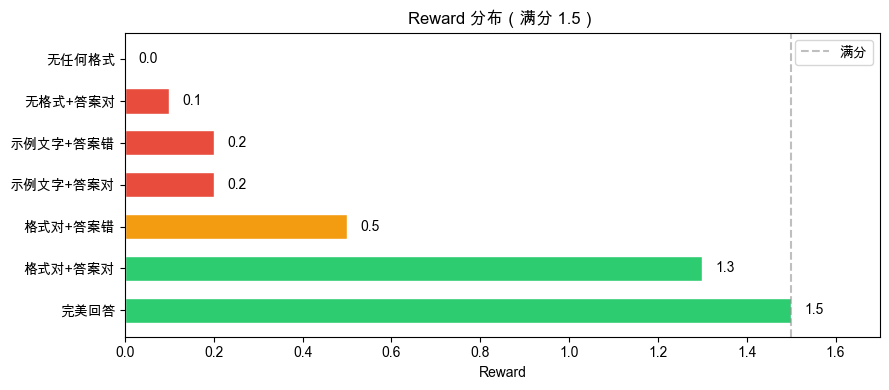

In [9]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial Unicode MS'  # Mac 中文字体

scenarios = [
    ("完美回答",       1.5),
    ("格式对+答案对",  1.3),   # 缺 think
    ("格式对+答案错",  0.5),
    ("示例文字+答案对", 0.2),  # baseline 侥幸对
    ("示例文字+答案错", 0.2),  # baseline 典型
    ("无格式+答案对",   0.1),  # 只有 answer 标签且对
    ("无任何格式",      0.0),
]

labels = [s[0] for s in scenarios]
values = [s[1] for s in scenarios]
colors = ["#2ecc71" if v >= 1.0 else "#f39c12" if v >= 0.3 else "#e74c3c" for v in values]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(labels, values, color=colors, edgecolor="white", height=0.6)
ax.set_xlim(0, 1.7)
ax.set_xlabel("Reward")
ax.set_title("Reward 分布（满分 1.5）")
ax.axvline(1.5, color="gray", linestyle="--", alpha=0.5, label="满分")
for bar, val in zip(bars, values):
    ax.text(val + 0.03, bar.get_y() + bar.get_height()/2, f"{val}", va="center", fontsize=10)
ax.legend()
plt.tight_layout()
plt.show()

## 8. GRPO 的 Reward 接口说明

TRL 的 `GRPOTrainer` 要求 reward 函数签名如下：

```python
def reward_fn(completions, **kwargs) -> list[float]
```

`**kwargs` 里包含数据集的其他字段（比如 `answer`）。下面写好供 03 直接 import 的版本。

In [10]:
# 供 GRPOTrainer 使用的 reward 函数
# completions 是字符串列表（每个是模型一次完整生成）
# kwargs["answer"] 是对应的正确答案列表

def grpo_reward_fn(completions: list[str], **kwargs) -> list[float]:
    answers = kwargs["answer"]
    return reward_fn(completions, answers)


# 快速验证接口
test_completions = [
    "<think>48+24=72</think><tool_call>48+48/2</tool_call><answer>72</answer>",
    "<tool_call>Python 表达式</tool_call><answer>72</answer>",
]
test_answers = ["72", "72"]

rewards = grpo_reward_fn(test_completions, answer=test_answers)
print("GRPO reward 接口验证：")
for c, r in zip(test_completions[:1], rewards[:1]):
    print(f"  完美输出 => reward={r}")
print(f"  示例文字 => reward={rewards[1]}")

GRPO reward 接口验证：
  完美输出 => reward=1.5
  示例文字 => reward=1.2


## 9. 小结

**Reward 函数设计完成：**

| 分项 | 满分 | 触发条件 |
|---|---|---|
| 格式奖励 | 0.3 | `<think>` + `<tool_call>` + `<answer>` 均存在 |
| 工具执行奖励 | 0.2 | `tool_call` 内容可被 Python eval 执行 |
| 结果奖励 | 1.0 | `answer` 与正确答案数字一致 |
| **合计** | **1.5** | |

**Baseline reward**：约 0.1-0.2（主要因为格式不稳定、tool_call 填示例文字）

**训练目标**：GRPO 训练后，平均 reward 能从 ~0.15 提升到 ~1.0+

**下一步**：`03_grpo_training.ipynb` — 用 TRL GRPOTrainer 跑训练循环